In [6]:
import pandas as pd
import numpy as np

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Load Dataset
df = pd.read_csv("Recipies-Dataset.csv")
if 'health_tags' in df.columns:
    df = df.drop(columns=['health_tags'])
df.head()

,recipe_id,name,cuisine,category,ingredients,steps,calories,veg,flavor_profile,season,suitable_for_diabetes,suitable_for_bp,suitable_for_heart_condition
0,1,Garlic Naan,Pakistani,Bread,"500g Wheat/All-purpose flour, 1 cup Water, 2 t...",1. Sieve the flour and add salt and water grad...,352,yes,Savory,All,yes,maybe,no
1,2,Tandoori Naan,Pakistani,Bread,"500g Wheat/All-purpose flour, 1 cup Water, 2 t...",1. Sieve the flour and add salt and water grad...,173,yes,Savory,All,yes,yes,yes
2,3,Dahi Bhallay,Pakistani,Snack,"Flour/Besan, Lemon, Oil for frying, Spices","1. In a large bowl, mix the base ingredients w...",310,yes,Savory,All,yes,yes,yes
3,4,Bun Kebab,Pakistani,Snack,"Flour/Besan, Potato, Oil for frying, Spices","1. In a large bowl, mix the base ingredients w...",256,no,Spicy,All,yes,yes,no
4,5,Chicken Biryani,Pakistani,Rice,"500g Basmati Rice, Sugar, Whole spices, Ghee",1. Wash the rice multiple times until the wate...,790,no,Spicy,All,no,maybe,no


In [9]:
#  Clean text columns
df['name'] = df['name'].str.lower().str.strip()
df['ingredients'] = df['ingredients'].str.lower()
df['steps'] = df['steps'].str.lower()
#df['category'] = df['category'].str.lower().str.strip()
df['category'] = df['category'].astype(str).str.lower().str.strip()
df['flavor_profile'] = df['flavor_profile'].str.lower().str.strip()
df['season'] = df['season'].str.lower().str.strip()

In [10]:
# Convert veg column
df['veg'] = df['veg'].map({'yes': 1, 'no': 0})

In [11]:
# Convert health columns to int
health_cols = ['suitable_for_diabetes', 'suitable_for_bp', 'suitable_for_heart_condition']

for col in health_cols:
    df[col] = df[col].str.lower().str.strip()  # clean text first
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [12]:
# Feature Engineering
df['ingredients_length'] = df['ingredients'].apply(lambda x: len(str(x).split(',')))
df['steps_length'] = df['steps'].apply(lambda x: len(str(x).split('.')))

In [13]:
# Remove poor quality rows
df = df[(df['ingredients_length'] > 2) & (df['steps_length'] > 2)]

In [14]:
# Create health_tags column
def get_health_tags(row):
    tags = []
    if row['suitable_for_diabetes'] == 1:
        tags.append('diabetic')
    if row['suitable_for_bp'] == 1:
        tags.append('bp')
    if row['suitable_for_heart_condition'] == 1:
        tags.append('heart')
    return ','.join(tags)

df['health_tags'] = df.apply(get_health_tags, axis=1)

In [15]:
# Save cleaned dataset
df.to_csv("Cleaned-Recipies-dataset.csv", index=False)
print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


In [16]:
# For good visuals
sns.set_style("whitegrid")

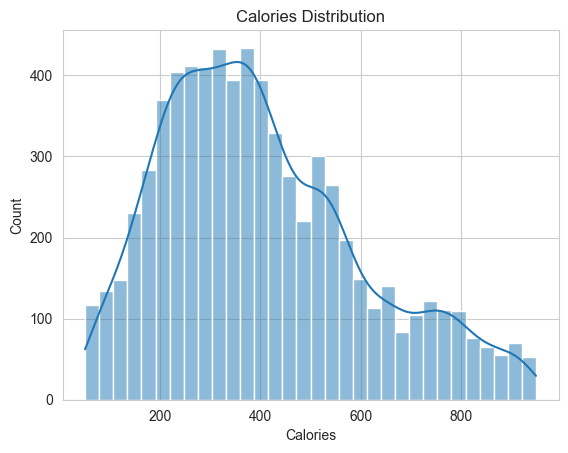

In [17]:
# Calories Distribution (Histogram)
plt.figure()
sns.histplot(df['calories'], kde=True)
plt.title("Calories Distribution")
plt.xlabel("Calories")
plt.ylabel("Count")
plt.show()

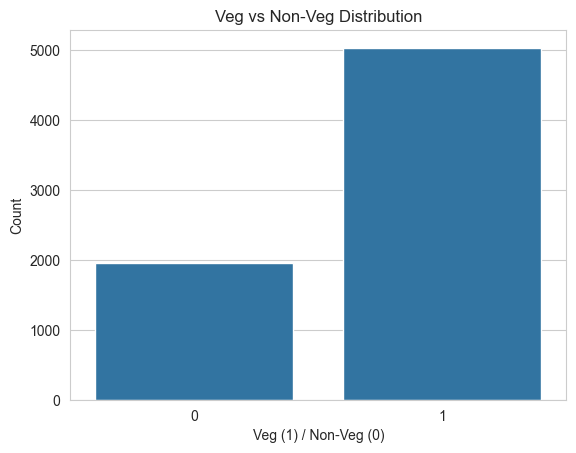

In [18]:
# Veg vs Non-Veg Count Plot
plt.figure()
sns.countplot(x='veg', data=df)
plt.title("Veg vs Non-Veg Distribution")
plt.xlabel("Veg (1) / Non-Veg (0)")
plt.ylabel("Count")
plt.show()

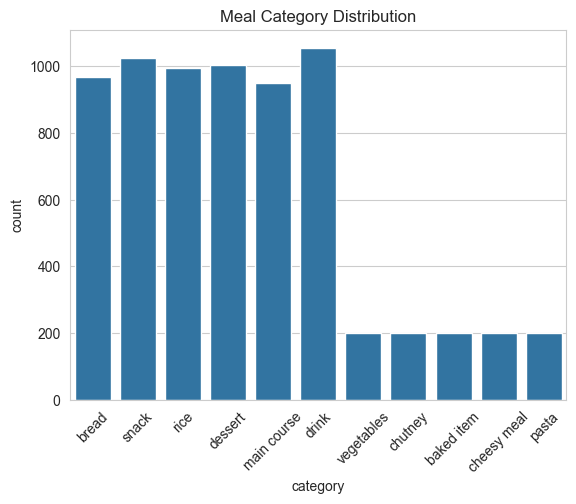

In [19]:
# Category Distribution
plt.figure()
sns.countplot(x='category', data=df)
plt.title("Meal Category Distribution")
plt.xticks(rotation=45)
plt.show()

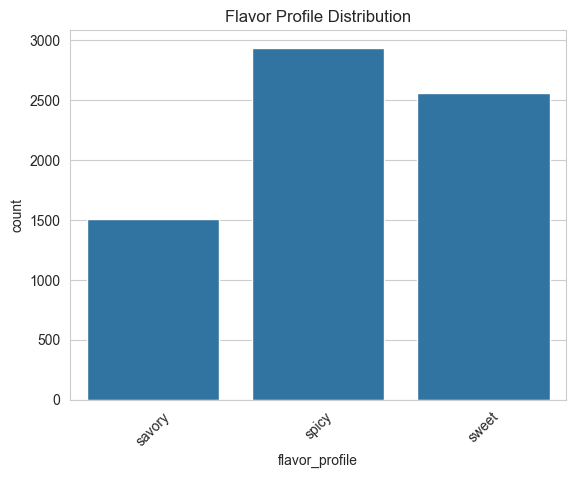

In [20]:
# Flavor Profile Distribution
plt.figure()
sns.countplot(x='flavor_profile', data=df)
plt.title("Flavor Profile Distribution")
plt.xticks(rotation=45)
plt.show()

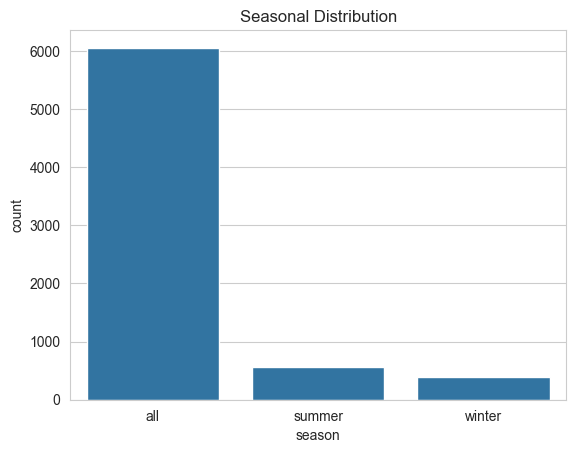

In [21]:
# Season Distribution
plt.figure()
sns.countplot(x='season', data=df)
plt.title("Seasonal Distribution")
plt.show()

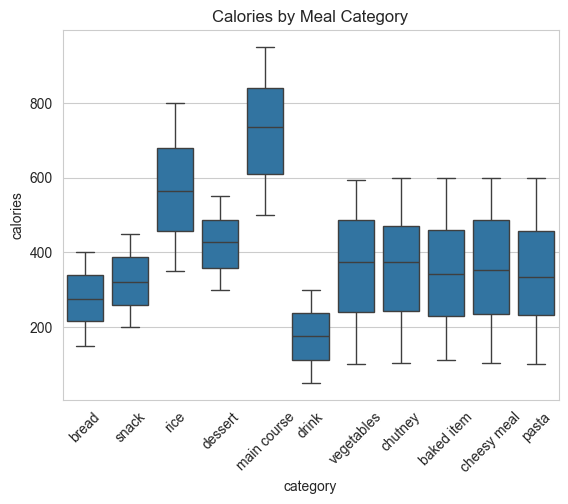

In [22]:
# Calories vs Category
plt.figure()
sns.boxplot(x='category', y='calories', data=df)
plt.title("Calories by Meal Category")
plt.xticks(rotation=45)
plt.show()

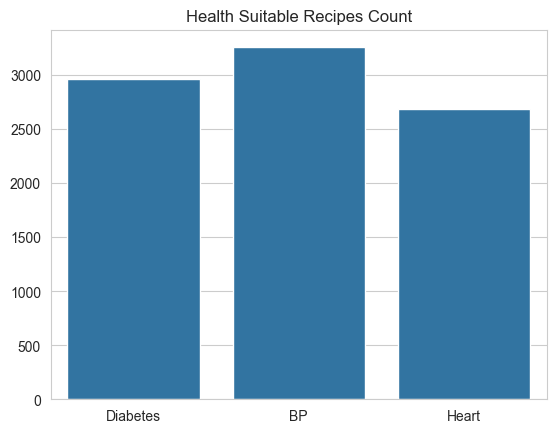

In [23]:
# Health Conditions Count
health_counts = [
    df['suitable_for_diabetes'].sum(),
    df['suitable_for_bp'].sum(),
    df['suitable_for_heart_condition'].sum()
]

labels = ['Diabetes', 'BP', 'Heart']

plt.figure()
sns.barplot(x=labels, y=health_counts)
plt.title("Health Suitable Recipes Count")
plt.show()

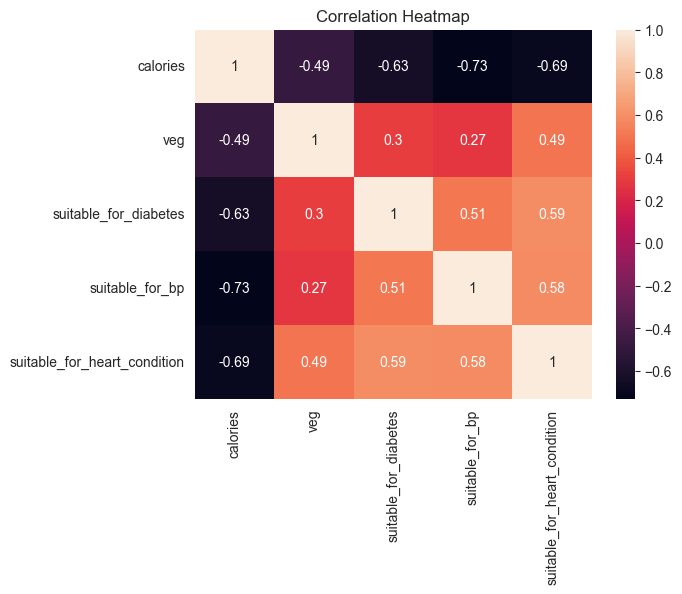

In [24]:
# Correlation Heatmap
plt.figure()
sns.heatmap(df[['calories','veg',
                'suitable_for_diabetes',
                'suitable_for_bp',
                'suitable_for_heart_condition']].corr(),
            annot=True)

plt.title("Correlation Heatmap")
plt.show()

In [25]:
# Import Libraries for Recommendation System
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import random

In [26]:
# Load Cleaned Dataset
df = pd.read_csv("Cleaned-Recipies-dataset.csv")

df.head()

,recipe_id,name,cuisine,category,ingredients,steps,calories,veg,flavor_profile,season,suitable_for_diabetes,suitable_for_bp,suitable_for_heart_condition,ingredients_length,steps_length,health_tags
0,1,garlic naan,Pakistani,bread,"500g wheat/all-purpose flour, 1 cup water, 2 t...",1. sieve the flour and add salt and water grad...,352,1,savory,all,1,NaN,0,4,11,diabetic
1,2,tandoori naan,Pakistani,bread,"500g wheat/all-purpose flour, 1 cup water, 2 t...",1. sieve the flour and add salt and water grad...,173,1,savory,all,1,1.0,1,4,11,"diabetic,bp,heart"
2,3,dahi bhallay,Pakistani,snack,"flour/besan, lemon, oil for frying, spices","1. in a large bowl, mix the base ingredients w...",310,1,savory,all,1,1.0,1,4,13,"diabetic,bp,heart"
3,4,bun kebab,Pakistani,snack,"flour/besan, potato, oil for frying, spices","1. in a large bowl, mix the base ingredients w...",256,0,spicy,all,1,1.0,0,4,13,"diabetic,bp"
4,5,chicken biryani,Pakistani,rice,"500g basmati rice, sugar, whole spices, ghee",1. wash the rice multiple times until the wate...,790,0,spicy,all,0,NaN,0,4,13,NaN


In [27]:
# Combine Text Features
df['combined'] = df['ingredients'] + " " + df['steps'] + " " + df['name']

In [28]:
# Apply TF-IDF
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['combined'])
print("TF-IDF Applied")
print("Matrix Shape:", tfidf_matrix.shape)

TF-IDF Applied
Matrix Shape: (7000, 519)


In [29]:
# Recommendation Function
def recommend_meals(user_input):

    user_vec = tfidf.transform([user_input])

    similarity = cosine_similarity(user_vec, tfidf_matrix)

    scores = list(enumerate(similarity[0]))

    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    top_indices = [i[0] for i in scores[:10]]

    return df.iloc[top_indices]

In [30]:
# Test Recommendation
test_input = "chicken spicy low calorie"
result = recommend_meals(test_input)
print("\nTop Recommendations:\n")
for i, row in result.iterrows():

    print("Recipe:", row['name'])
    print("Category:", row['category'])
    print("----------------------")


Top Recommendations:

Recipe: spicy spaghetti 2
Category: pasta
----------------------
Recipe: spicy spaghetti 7
Category: pasta
----------------------
Recipe: spicy spaghetti 9
Category: pasta
----------------------
Recipe: spicy spaghetti 11
Category: pasta
----------------------
Recipe: spicy spaghetti 23
Category: pasta
----------------------
Recipe: spicy spaghetti 29
Category: pasta
----------------------
Recipe: spicy spaghetti 32
Category: pasta
----------------------
Recipe: spicy spaghetti 51
Category: pasta
----------------------
Recipe: spicy spaghetti 52
Category: pasta
----------------------
Recipe: spicy spaghetti 53
Category: pasta
----------------------


In [31]:
# 7-Day Meal Planner
def generate_meal_plan(user_input):
    recommendations = recommend_meals(user_input)
    meal_plan = {}
    for day in range(1, 8):

        breakfast = recommendations[recommendations['category'] == 'breakfast']
        lunch = recommendations[recommendations['category'] == 'lunch']
        dinner = recommendations[recommendations['category'] == 'dinner']

        if breakfast.empty:
            breakfast = recommendations

        if lunch.empty:
            lunch = recommendations

        if dinner.empty:
            dinner = recommendations

        meal_plan[f"Day {day}"] = {
            "Breakfast": breakfast.sample(1)['name'].values[0],
            "Lunch": lunch.sample(1)['name'].values[0],
            "Dinner": dinner.sample(1)['name'].values[0]
        }

    return meal_plan

In [32]:
# User Input and Meal Plan Generation
user_input = input("Enter your preference (e.g., chicken, spicy, low calorie): ")
meal_plan = generate_meal_plan(user_input)
print("\nYour 7-Day Meal Plan\n")
for day, meals in meal_plan.items():
    print(day)
    print("Breakfast:", meals["Breakfast"])
    print("Lunch:", meals["Lunch"])
    print("Dinner:", meals["Dinner"])
    print("---------------------")

Enter your preference (e.g., chicken, spicy, low calorie):  vegetarian



Your 7-Day Meal Plan

Day 1
Breakfast: mutton jalfrezi
Lunch: chicken biryani
Dinner: bun kebab
---------------------
Day 2
Breakfast: chana pulao
Lunch: garlic naan
Dinner: bun kebab
---------------------
Day 3
Breakfast: dahi bhallay
Lunch: dahi bhallay
Dinner: dahi bhallay
---------------------
Day 4
Breakfast: prawns haleem
Lunch: garlic naan
Dinner: chana pulao
---------------------
Day 5
Breakfast: chicken biryani
Lunch: dahi bhallay
Dinner: garlic naan
---------------------
Day 6
Breakfast: chana pulao
Lunch: suji ka halwa
Dinner: pakora
---------------------
Day 7
Breakfast: suji ka halwa
Lunch: chicken biryani
Dinner: mutton jalfrezi
---------------------


In [33]:
# Confirmation
confirm = input("Do you like this plan? (yes/no): ")
if confirm.lower() == "yes":
    print("\nMeal Plan Confirmed!")
else:
    print("\nGenerating New Plan...\n")
    meal_plan = generate_meal_plan(user_input)
    for day, meals in meal_plan.items():
        print(day)
        print("Breakfast:", meals["Breakfast"])
        print("Lunch:", meals["Lunch"])
        print("Dinner:", meals["Dinner"])
        print("---------------------")

Do you like this plan? (yes/no):  no



Generating New Plan...

Day 1
Breakfast: dahi bhallay
Lunch: chana pulao
Dinner: garlic naan
---------------------
Day 2
Breakfast: pakora
Lunch: mutton jalfrezi
Dinner: chicken biryani
---------------------
Day 3
Breakfast: chana pulao
Lunch: mutton jalfrezi
Dinner: mutton jalfrezi
---------------------
Day 4
Breakfast: prawns haleem
Lunch: tandoori naan
Dinner: tandoori naan
---------------------
Day 5
Breakfast: mutton jalfrezi
Lunch: pakora
Dinner: tandoori naan
---------------------
Day 6
Breakfast: tandoori naan
Lunch: mutton jalfrezi
Dinner: chana pulao
---------------------
Day 7
Breakfast: suji ka halwa
Lunch: mutton jalfrezi
Dinner: bun kebab
---------------------


In [34]:
# Evalution Metrics Precision@K Evaluation
def precision_at_k(user_input, k=10):
    recommendations = recommend_meals(user_input)
    relevant = 0
    for _, row in recommendations.head(k).iterrows():
        if any(word in row['combined'] for word in user_input.split()):
            relevant += 1
    precision = relevant / k
    return precision
query = "chicken spicy low calorie"
print("Precision@10:", precision_at_k(query))

Precision@10: 1.0


In [35]:
# Recall@K Evaluation
def recall_at_k(user_input, k=10):
    recommendations = recommend_meals(user_input)
    relevant_in_top_k = 0
    total_relevant = 0
    for _, row in df.iterrows():
        if any(word in row['combined'] for word in user_input.split()):
            total_relevant += 1
    for _, row in recommendations.head(k).iterrows():

        if any(word in row['combined'] for word in user_input.split()):
            relevant_in_top_k += 1
    if total_relevant == 0:
        return 0
    recall = relevant_in_top_k / total_relevant
    return recall
print("Recall@10:", recall_at_k(query))

Recall@10: 0.0021668472372697724


In [36]:
# Average Cosine Similarity Score
def average_similarity(user_input):
    user_vec = tfidf.transform([user_input])
    similarity = cosine_similarity(user_vec, tfidf_matrix)[0]
    top_scores = sorted(similarity, reverse=True)[:10]
    return np.mean(top_scores)
print("Avg Cosine Similarity:", average_similarity(query))

Avg Cosine Similarity: 0.2522196381065772


In [37]:
# Diversity Score Evaluation
def diversity_score(user_input):
    recommendations = recommend_meals(user_input)
    indices = recommendations.index[:10]
    if len(indices) < 2:
        return 0
    sim_matrix = cosine_similarity(tfidf_matrix[indices])
    diversity = 1 - np.mean(sim_matrix)
    return diversity
print("Diversity Score:", diversity_score(query))

Diversity Score: 0.05336381176098792
